# Customer Fraud Detection – Binary Classification


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [5]:
df = pd.read_csv('customer_analytics_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (5000, 13)


,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   str    
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   str    
 3   country             5000 non-null   str    
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   str    
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   str    
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), str(5)
memory usage: 684.8 KB


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,3809,CUST_5780,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,48.1632,17.880797,18.0,33.0,48.0,64.0,79.0
gender,5000,3,Male,2278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,Australia,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_order_value,4750.0,NaN,NaN,NaN,108.442857,69.265559,10.66,57.805,93.19,142.1975,555.46
total_orders,5000.0,NaN,NaN,NaN,10.027,3.163838,0.0,8.0,10.0,12.0,23.0
last_purchase,5000.0,NaN,NaN,NaN,180.0732,104.926518,0.0,89.0,178.0,270.0,364.0
is_fraudulent,5000.0,NaN,NaN,NaN,0.0258,0.158554,0.0,0.0,0.0,0.0,1.0
preferred_category,5000,5,Beauty,1035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email_open_rate,4750.0,NaN,NaN,NaN,50.714842,29.098706,0.0,25.225,50.95,76.8,100.0


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
avg_order_value,250,5.0
email_open_rate,250,5.0


In [9]:
dup_count = df.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")

Total duplicate rows: 0


is_fraudulent
0    4871
1     129
Name: count, dtype: int64

Percentage:
is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64


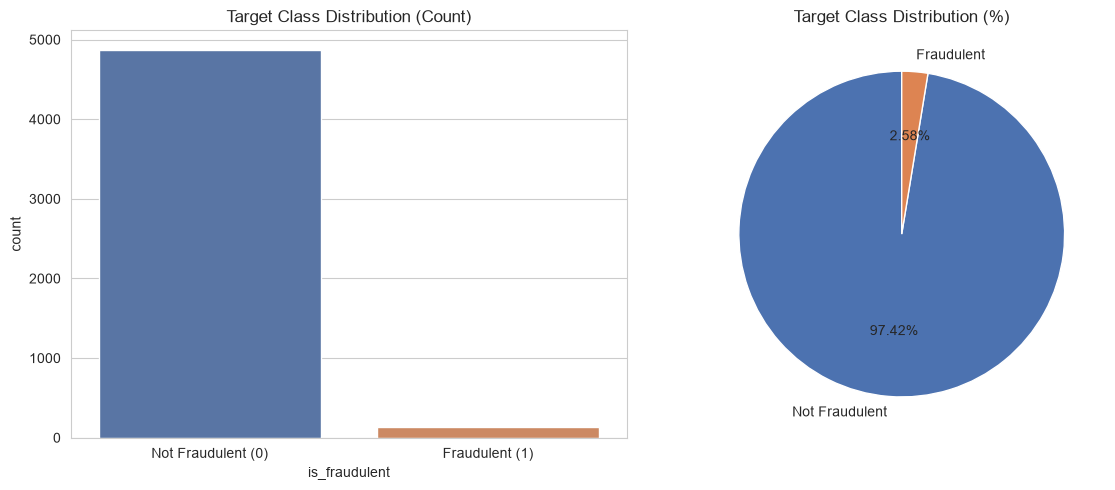

In [10]:
target_counts = df['is_fraudulent'].value_counts()
print(target_counts)
print("\nPercentage:")
print(df['is_fraudulent'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='is_fraudulent', data=df, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title('Target Class Distribution (Count)')
ax[0].set_xticklabels(['Not Fraudulent (0)', 'Fraudulent (1)'])

ax[1].pie(target_counts, labels=['Not Fraudulent', 'Fraudulent'], autopct='%1.2f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title('Target Class Distribution (%)')
plt.tight_layout()
plt.show()

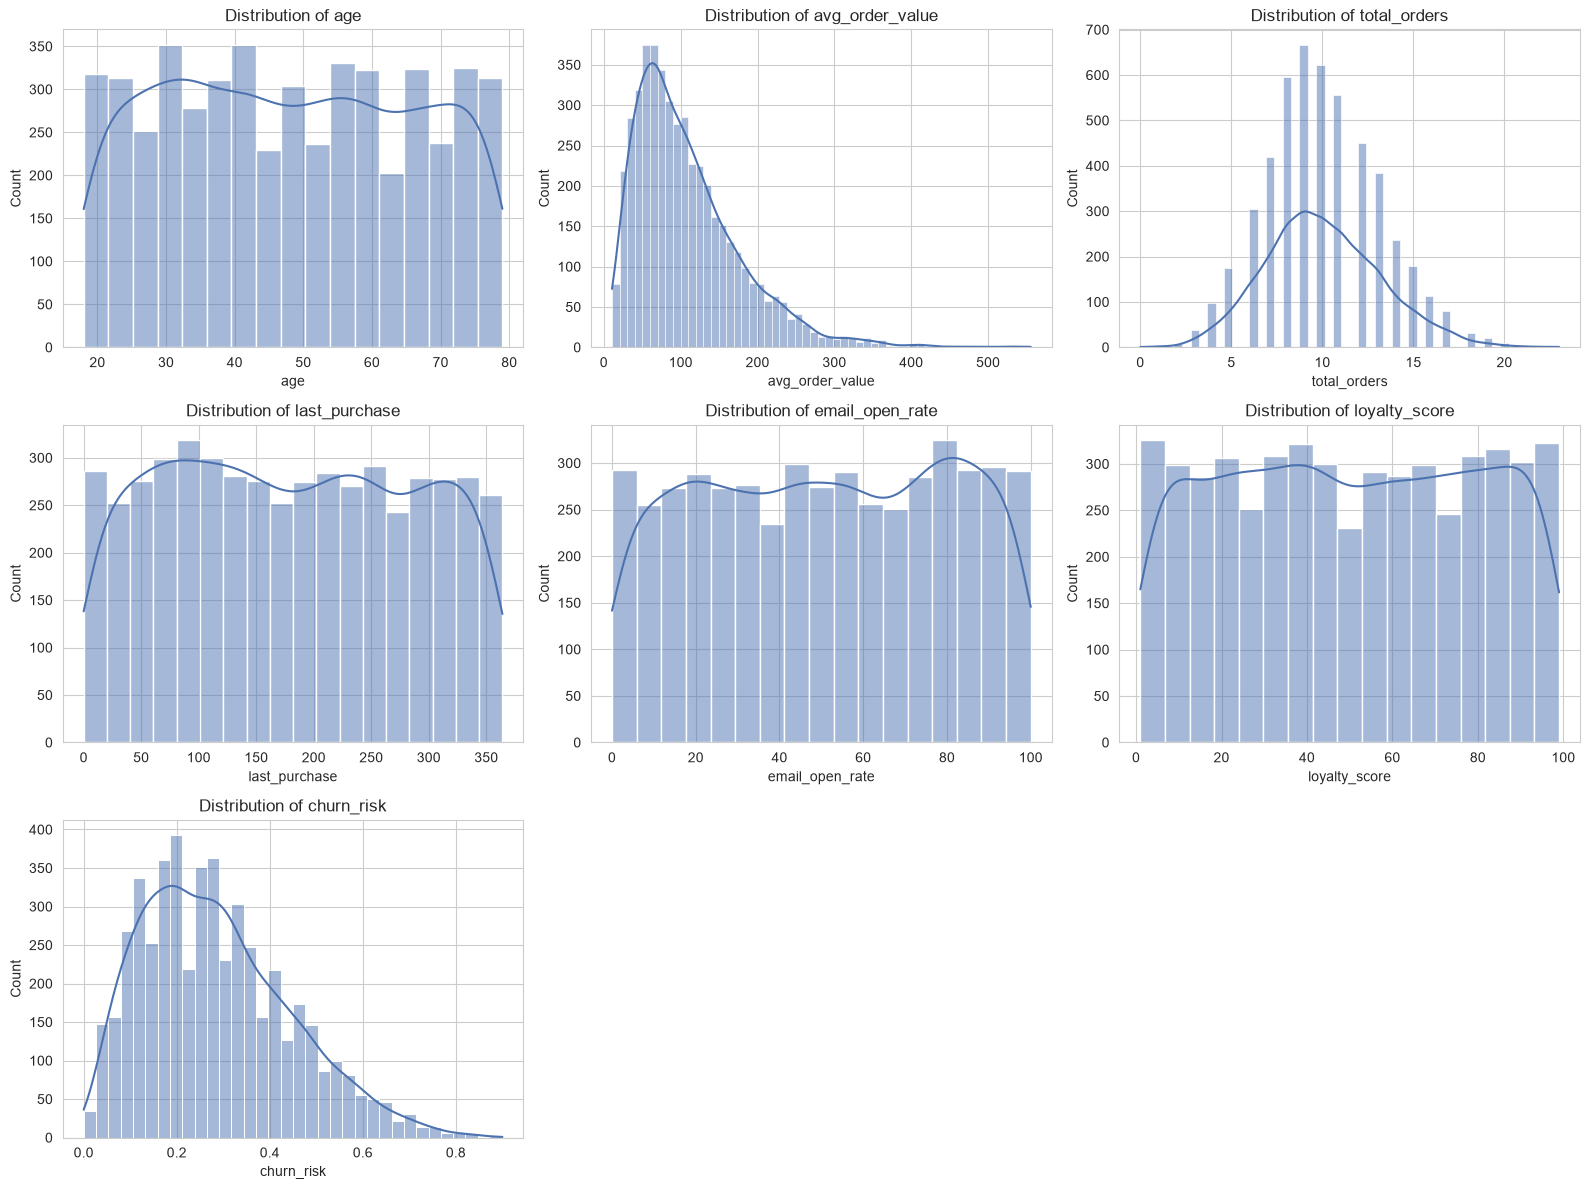

In [11]:
num_cols = ['age', 'avg_order_value', 'total_orders', 'last_purchase',
            'email_open_rate', 'loyalty_score', 'churn_risk']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

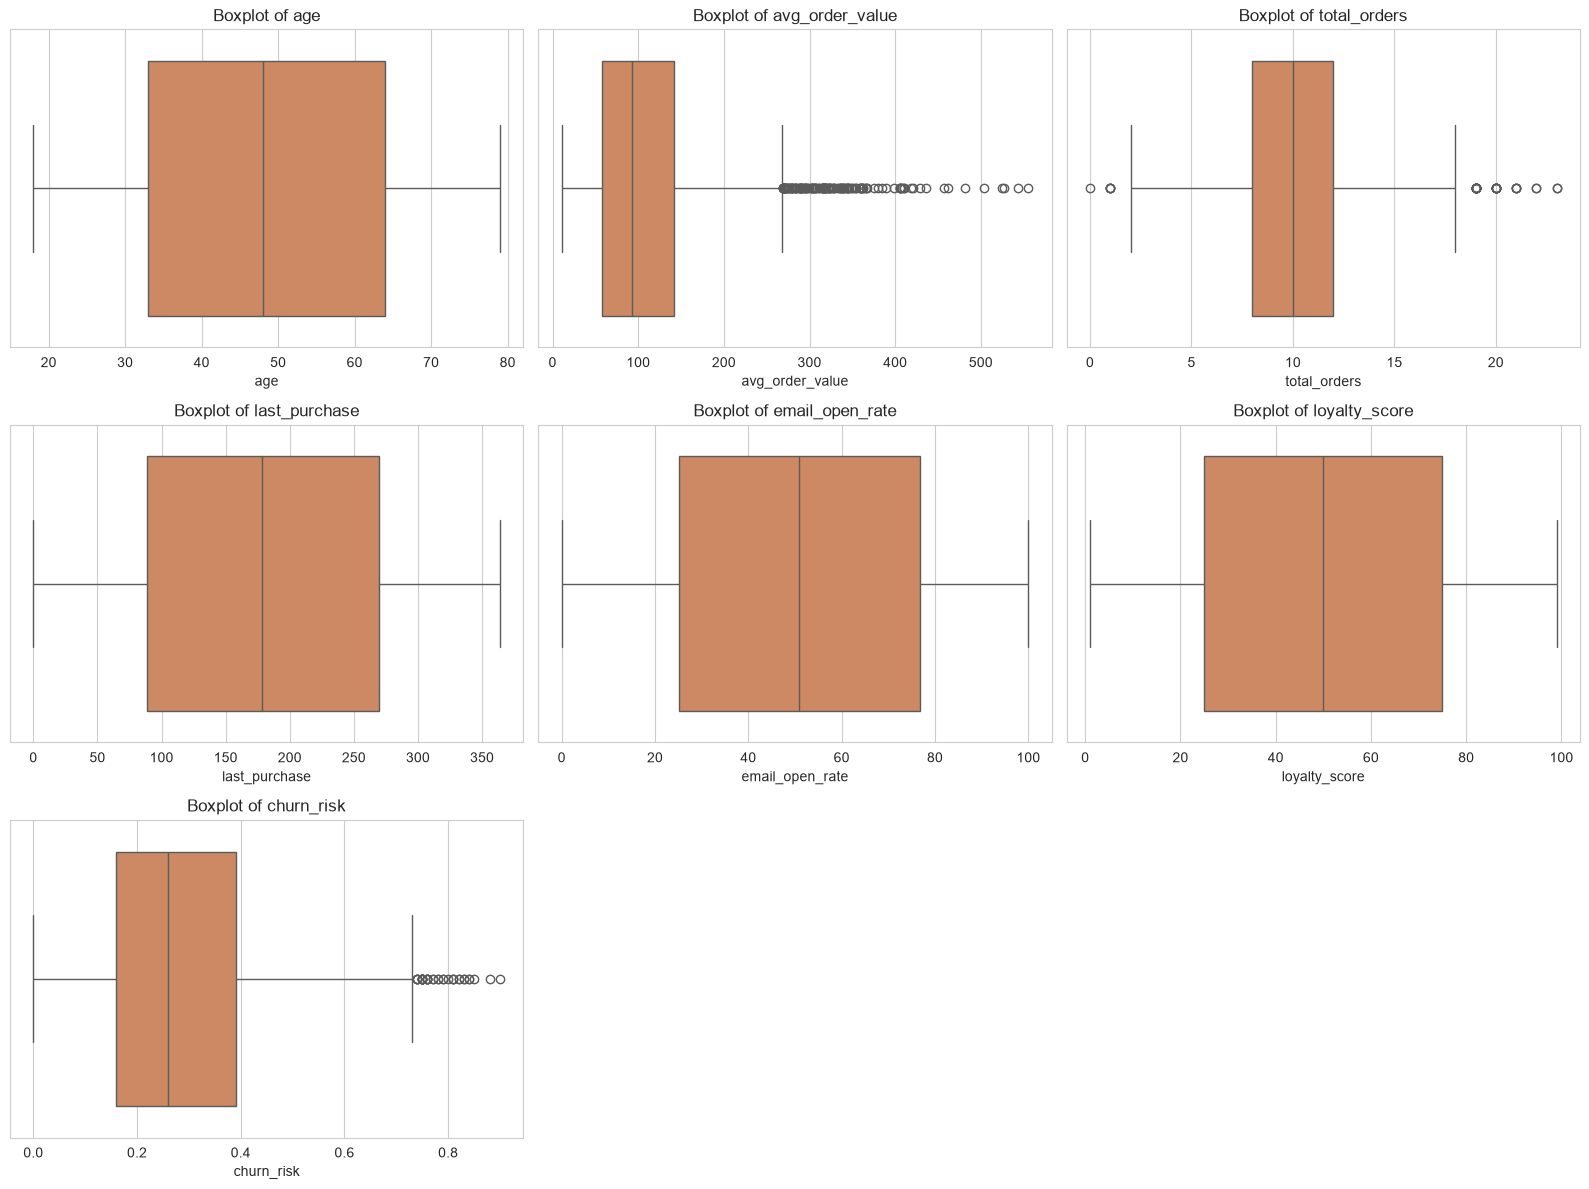

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#DD8452')
    axes[i].set_title(f'Boxplot of {col}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [13]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = {col: count_outliers_iqr(df[col].dropna()) for col in num_cols}
outlier_summary = pd.Series(outlier_summary, name='Outlier Count').sort_values(ascending=False)
outlier_summary

avg_order_value    137
total_orders        42
churn_risk          37
age                  0
last_purchase        0
email_open_rate      0
loyalty_score        0
Name: Outlier Count, dtype: int64

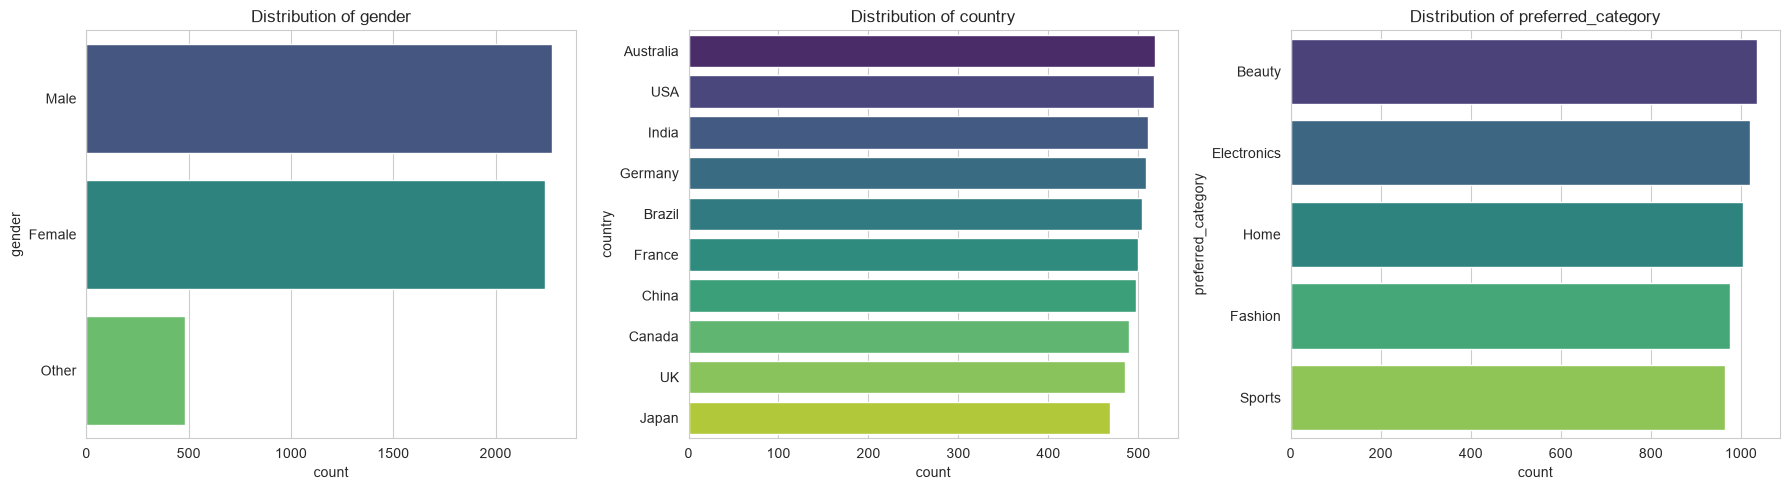

In [14]:
cat_cols = ['gender', 'country', 'preferred_category']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=df, ax=axes[i], order=df[col].value_counts().index, palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

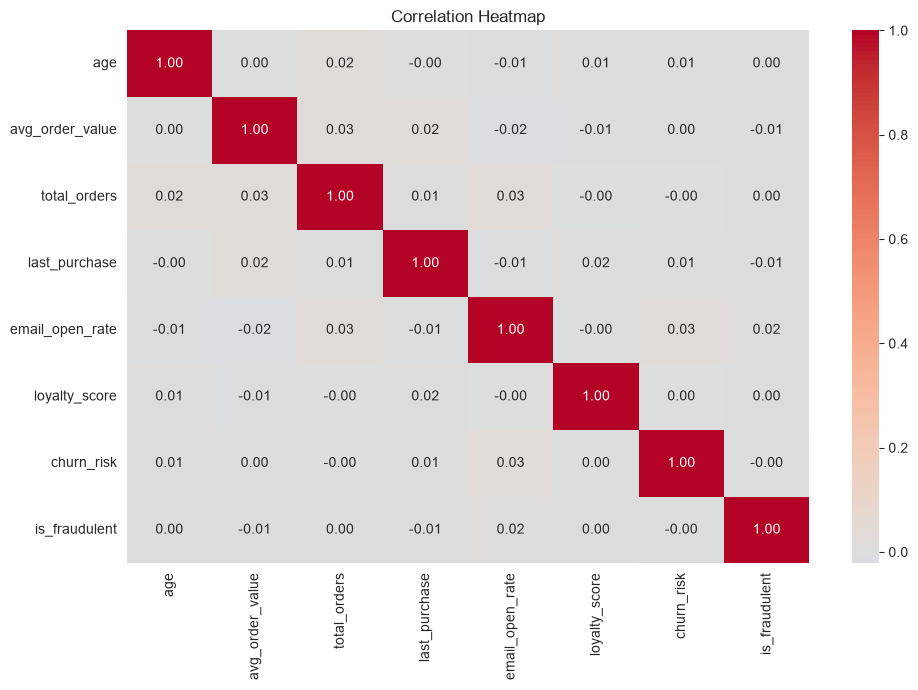

In [15]:
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['is_fraudulent']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

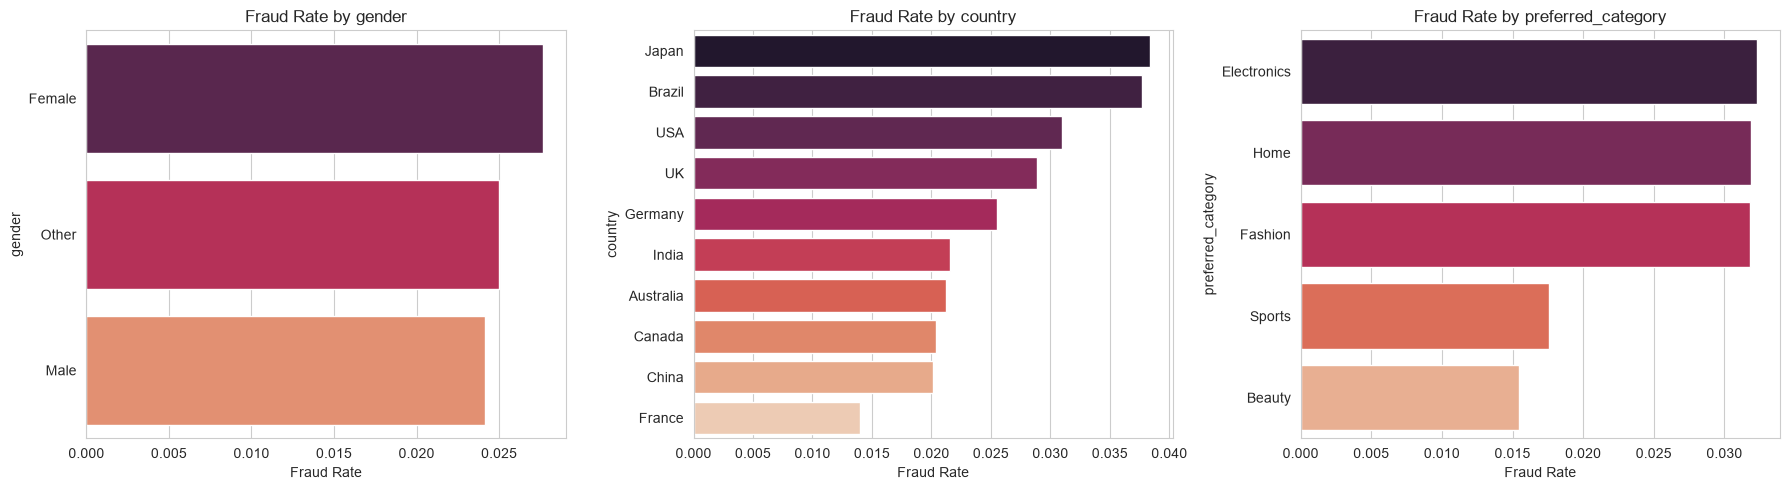

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['is_fraudulent'].mean().sort_values(ascending=False)
    sns.barplot(x=fraud_rate.values, y=fraud_rate.index, ax=axes[i], palette='rocket')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xlabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [17]:
df['avg_order_value'] = df['avg_order_value'].fillna(df['avg_order_value'].median())
df['email_open_rate'] = df['email_open_rate'].fillna(df['email_open_rate'].median())

print("Missing values after imputation:")
print(df[['avg_order_value', 'email_open_rate']].isnull().sum())

Missing values after imputation:
avg_order_value    0
email_open_rate    0
dtype: int64


In [18]:
df['customer_since'] = pd.to_datetime(df['customer_since'])

reference_date = pd.to_datetime('2025-08-17')  # analysis reference date
df['customer_tenure_days'] = (reference_date - df['customer_since']).dt.days
df['customer_since_year'] = df['customer_since'].dt.year
df['customer_since_month'] = df['customer_since'].dt.month

df = df.drop(columns=['customer_since'])
df[['customer_tenure_days', 'customer_since_year', 'customer_since_month']].head()

,customer_tenure_days,customer_since_year,customer_since_month
0,438,2024,6
1,545,2024,2
2,488,2024,4
3,1866,2020,7
4,130,2025,4


In [19]:
df = df.drop(columns=['customer_id'])
print("Remaining columns:", list(df.columns))

Remaining columns: ['age', 'gender', 'country', 'avg_order_value', 'total_orders', 'last_purchase', 'is_fraudulent', 'preferred_category', 'email_open_rate', 'loyalty_score', 'churn_risk', 'customer_tenure_days', 'customer_since_year', 'customer_since_month']


In [20]:
cat_cols = ['gender', 'country', 'preferred_category']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (5000, 26)


,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,customer_since_year,...,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,preferred_category_Electronics,preferred_category_Fashion,preferred_category_Home,preferred_category_Sports
0,30,101.08,8,176,1,25.60,50,0.20,438,2024,...,False,False,False,False,False,False,False,False,False,False
1,53,90.39,10,88,0,12.30,37,0.34,545,2024,...,False,False,False,False,False,True,True,False,False,False
2,73,83.28,6,203,0,50.95,65,0.05,488,2024,...,False,False,False,False,False,False,False,False,False,True
3,30,109.90,9,346,1,42.90,93,0.19,1866,2020,...,False,False,False,True,False,False,True,False,False,False
4,29,269.38,16,342,0,5.30,79,0.15,130,2025,...,False,False,False,False,False,False,False,True,False,False


In [21]:
X = df_encoded.drop(columns=['is_fraudulent'])
y = df_encoded['is_fraudulent']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:", list(X.columns))

X shape: (5000, 25)
y shape: (5000,)

Feature columns: ['age', 'avg_order_value', 'total_orders', 'last_purchase', 'email_open_rate', 'loyalty_score', 'churn_risk', 'customer_tenure_days', 'customer_since_year', 'customer_since_month', 'gender_Male', 'gender_Other', 'country_Brazil', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Japan', 'country_UK', 'country_USA', 'preferred_category_Electronics', 'preferred_category_Fashion', 'preferred_category_Home', 'preferred_category_Sports']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts())
print("\nTest target distribution:\n", y_test.value_counts())

Train shape: (4000, 25)  Test shape: (1000, 25)

Train target distribution:
 is_fraudulent
0    3897
1     103
Name: count, dtype: int64

Test target distribution:
 is_fraudulent
0    974
1     26
Name: count, dtype: int64


Before SMOTE:
 is_fraudulent
0    3897
1     103
Name: count, dtype: int64

After SMOTE:
 is_fraudulent
0    3897
1    3897
Name: count, dtype: int64


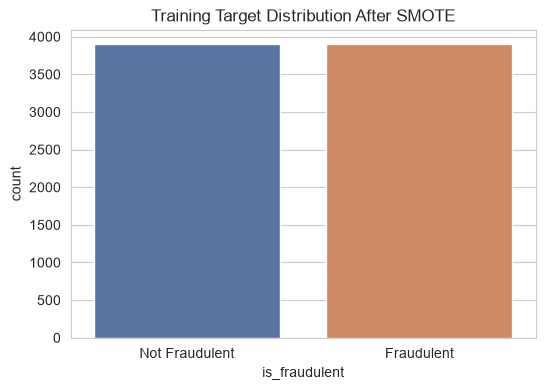

In [23]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_resampled.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette=['#4C72B0', '#DD8452'])
plt.title('Training Target Distribution After SMOTE')
plt.xticks([0, 1], ['Not Fraudulent', 'Fraudulent'])
plt.show()

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data sample:")
pd.DataFrame(X_train_scaled, columns=X.columns).head()

Scaled training data sample:


,age,avg_order_value,total_orders,last_purchase,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,customer_since_year,customer_since_month,...,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,preferred_category_Electronics,preferred_category_Fashion,preferred_category_Home,preferred_category_Sports
0,0.660828,0.120740,-0.307397,-0.248499,-0.076054,0.041273,1.301344,-0.963634,0.955941,0.214583,...,-0.342899,-0.409866,-0.397615,-0.481522,2.184796,-0.428275,-0.660418,-0.678506,-0.685372,-0.523199
1,0.049450,-0.681868,0.059165,1.508935,0.964009,0.115540,-1.536328,-0.581266,0.327410,1.459201,...,-0.342899,-0.409866,-0.397615,-0.481522,-0.457709,-0.428275,1.514191,-0.678506,-0.685372,-0.523199
2,1.577896,1.409630,0.059165,0.468220,1.011374,-1.703986,0.816863,0.497939,-0.301121,-0.718881,...,-0.342899,-0.409866,-0.397615,-0.481522,-0.457709,-0.428275,-0.660418,-0.678506,-0.685372,-0.523199
3,-1.478996,0.586292,-0.673959,-1.161579,1.311354,-1.406921,0.332383,1.159041,-0.929652,-1.030036,...,-0.342899,-0.409866,-0.397615,2.076748,-0.457709,-0.428275,-0.660418,-0.678506,-0.685372,-0.523199
4,0.171726,0.087856,-0.307397,0.713672,-1.893697,1.526601,-0.498155,-0.618788,0.327410,1.770356,...,-0.342899,-0.409866,2.514993,-0.481522,-0.457709,-0.428275,1.514191,-0.678506,-0.685372,-0.523199


In [25]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_resampled)
    preds = model.predict(X_test_scaled)
    trained_models[name] = model
    predictions[name] = preds
    print(f"{name} trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.
Logistic Regression trained successfully.


In [26]:
results = []

for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.907,0.041096,0.115385,0.060606
1,Random Forest,0.958,0.000000,0.000000,0.000000
2,XGBoost,0.962,0.000000,0.000000,0.000000
3,Logistic Regression,0.967,0.000000,0.000000,0.000000


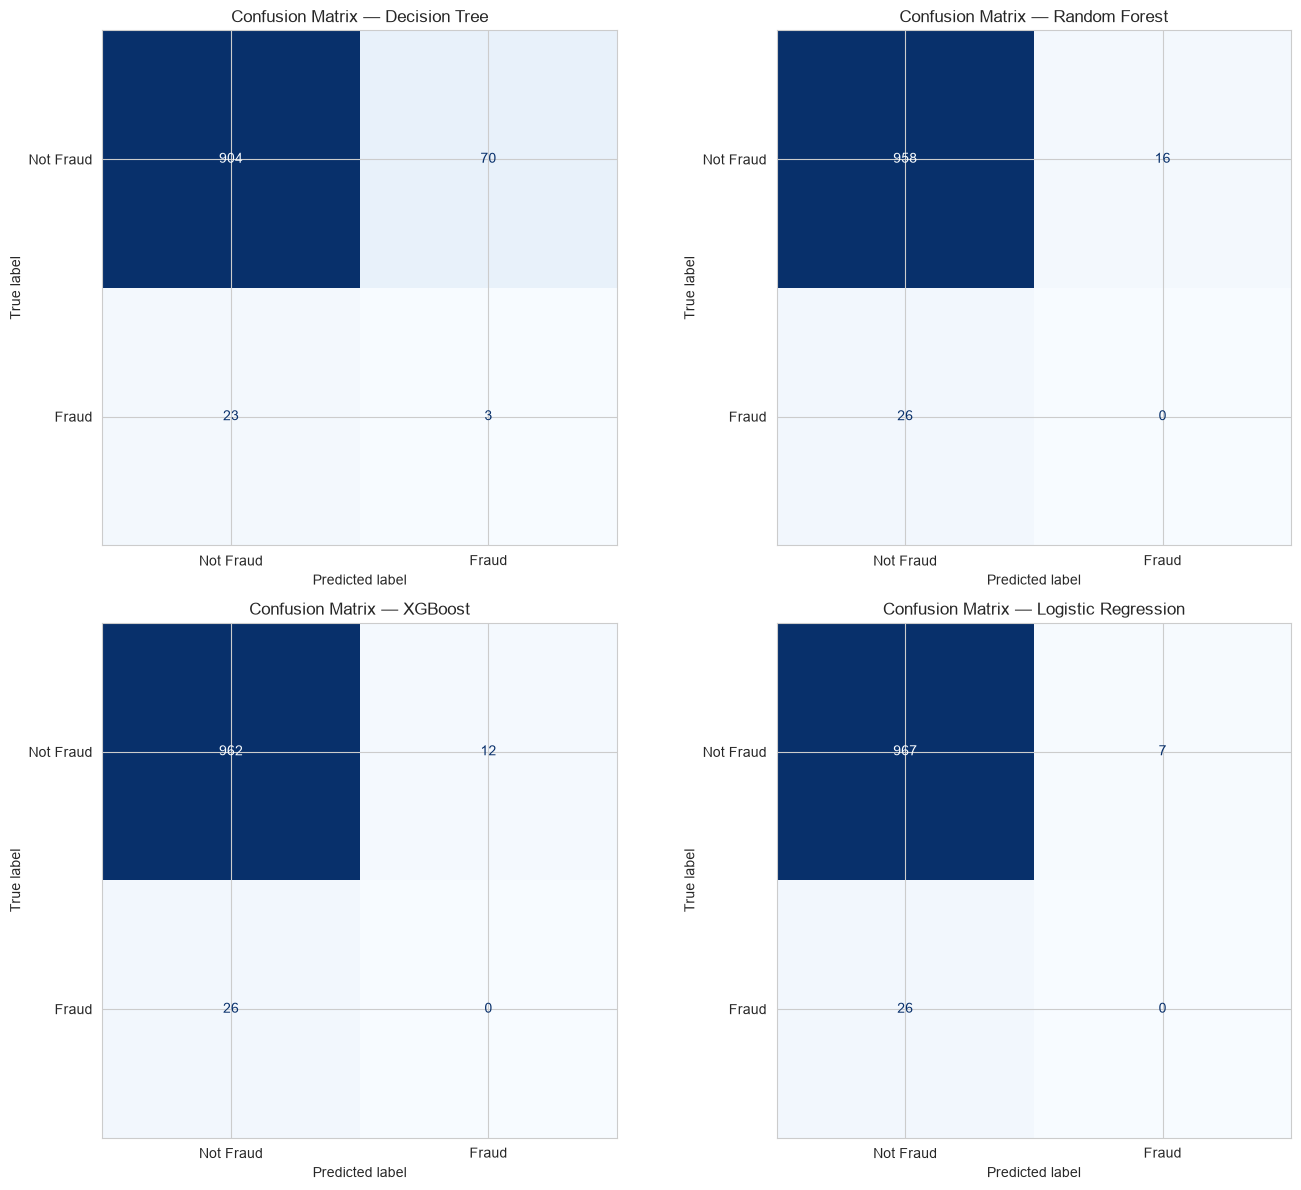

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.show()

In [28]:
for name, preds in predictions.items():
    print(f"{'='*60}")
    print(f"Classification Report — {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, preds, target_names=['Not Fraudulent', 'Fraudulent'], zero_division=0))

Classification Report — Decision Tree
                precision    recall  f1-score   support

Not Fraudulent       0.98      0.93      0.95       974
    Fraudulent       0.04      0.12      0.06        26

      accuracy                           0.91      1000
     macro avg       0.51      0.52      0.51      1000
  weighted avg       0.95      0.91      0.93      1000

Classification Report — Random Forest
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.98      0.98       974
    Fraudulent       0.00      0.00      0.00        26

      accuracy                           0.96      1000
     macro avg       0.49      0.49      0.49      1000
  weighted avg       0.95      0.96      0.95      1000

Classification Report — XGBoost
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.99      0.98       974
    Fraudulent       0.00      0.00      0.00        26

      accuracy                           0.9

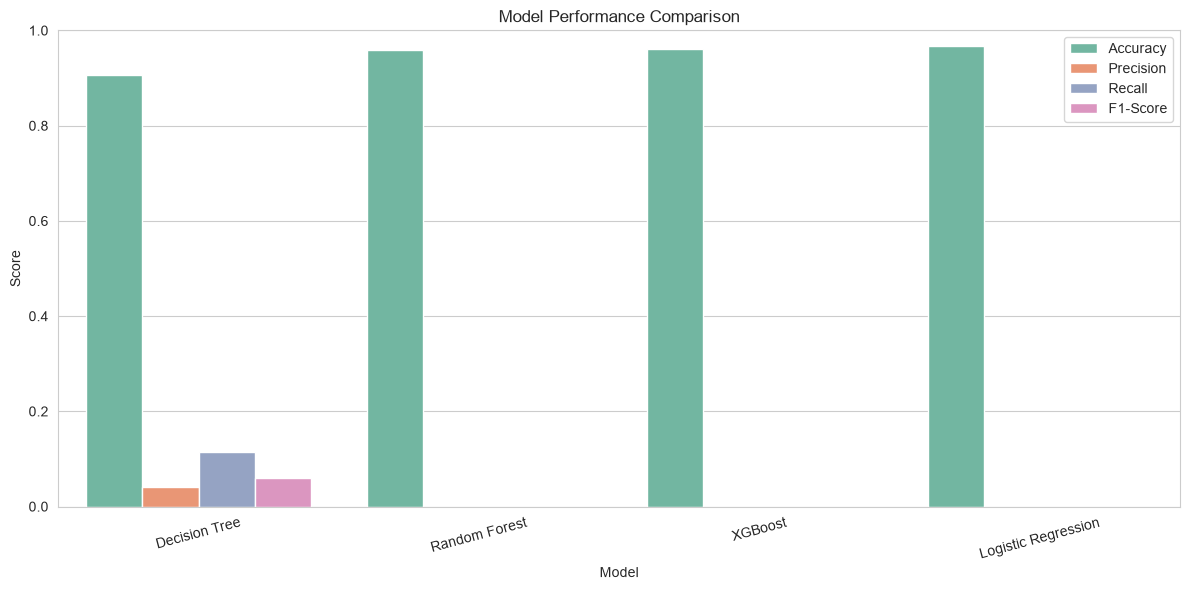

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.907,0.041096,0.115385,0.060606
1,Random Forest,0.958,0.000000,0.000000,0.000000
2,XGBoost,0.962,0.000000,0.000000,0.000000
3,Logistic Regression,0.967,0.000000,0.000000,0.000000


In [29]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='Set2')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

results_df

In [30]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Performing Model (by F1-Score): {best_model_name}")
print(f"\nFinal Performance:")
print(results_df.iloc[0])

Best Performing Model (by F1-Score): Decision Tree

Final Performance:
Model        Decision Tree
Accuracy             0.907
Precision         0.041096
Recall            0.115385
F1-Score          0.060606
Name: 0, dtype: object


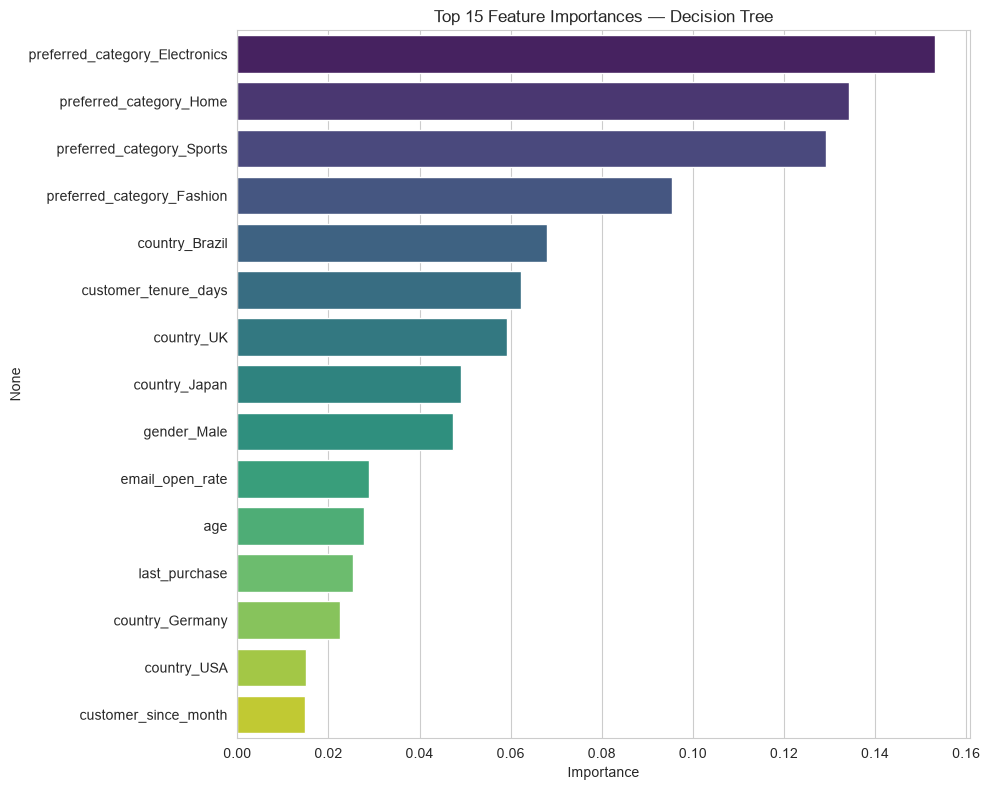

In [31]:
if best_model_name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15], palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("Best model is not tree-based, skipping feature importance plot.")